In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

import torch
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

In [2]:
#df = pd.read_excel("CustomerChurn_data.xlsx")
#print(df.info())
#print(df.head())
#print(df.describe())

#for col in df.columns:

#  print(col, "->", df[col].unique())

# Processing Data

In [3]:
def process_data(filename, /):

  if not isinstance(filename, str):

    raise TypeError

  df = pd.read_excel(filename)

  df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

  df.dropna(inplace = True)

  df.drop_duplicates(inplace = True)

  df.reset_index(drop = True, inplace = True)

  df.drop("customerID", axis = 1, inplace = True)

  df["gender"] = df["gender"].apply(lambda x: 1 if x == "Female" else 0)

  yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

  df[yes_no_cols] = df[yes_no_cols].map(lambda x: 1 if x == "Yes" else 0)

  cols_to_encode = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]

  encoder = OrdinalEncoder(categories=[
    ["No", "Yes", "No phone service"],           # MultipleLines
    ["No", "DSL", "Fiber optic"],                # InternetService
    ["No", "Yes", "No internet service"],        # OnlineSecurity
    ["No", "Yes", "No internet service"],        # OnlineBackup
    ["No", "Yes", "No internet service"],        # DeviceProtection
    ["No", "Yes", "No internet service"],        # TechSupport
    ["No", "Yes", "No internet service"],        # StreamingTV
    ["No", "Yes", "No internet service"],        # StreamingMovies
    ["Month-to-month", "One year", "Two year"],  # Contract
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]])

  df[cols_to_encode] = encoder.fit_transform(df[cols_to_encode])

  scaler = MinMaxScaler()

  feature_cols = df.drop(["Churn"] + cols_to_encode, axis = 1).columns

  df[feature_cols] = scaler.fit_transform(df[feature_cols])

  return df

In [4]:
df = process_data("CustomerChurn_data.xlsx")
print(df.head())

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     1.0            0.0      1.0         0.0  0.000000           0.0   
1     0.0            0.0      0.0         0.0  0.464789           1.0   
2     0.0            0.0      0.0         0.0  0.014085           1.0   
3     0.0            0.0      0.0         0.0  0.619718           0.0   
4     1.0            0.0      0.0         0.0  0.014085           1.0   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0            2.0              1.0             0.0           1.0   
1            0.0              1.0             1.0           0.0   
2            0.0              1.0             1.0           1.0   
3            2.0              1.0             1.0           0.0   
4            0.0              2.0             0.0           0.0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0               0.0          0.0          0.0              0.0       0.0   
1     

In [5]:
print(df["Churn"].value_counts()[0], "negative instances")
print(df["Churn"].value_counts()[1], "positive instances")

5163 negative instances
1869 positive instances


# Training, Validation & Testing

In [6]:
y_target = df["Churn"]
X_data = df.drop("Churn", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_target,
    test_size = 0.2, # 20% for testing
    random_state = 42,
    stratify = y_target
    )

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.125,       #10% of training for validation
    random_state = 42,
    stratify = y_train
    )

print("//--------Training Data---------//")
print(len(X_train), "total instances")
print("->", y_train.value_counts()[0], "negative instances")
print("->", y_train.value_counts()[1], "positive instances\n")

print("//--------Validation Data---------//")
print(len(X_val), "total instances")
print("->", y_val.value_counts()[0], "negative instances")
print("->", y_val.value_counts()[1], "positive instances\n")

print("//--------Testing Data---------//")
print(len(X_test), "total instances")
print("->", y_test.value_counts()[0], "negative instances")
print("->", y_test.value_counts()[1], "positive instances")

//--------Training Data---------//
4921 total instances
-> 3613 negative instances
-> 1308 positive instances

//--------Validation Data---------//
704 total instances
-> 517 negative instances
-> 187 positive instances

//--------Testing Data---------//
1407 total instances
-> 1033 negative instances
-> 374 positive instances


In [7]:
cols_to_encode = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
                  "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]

col_ids = [X_train.columns.get_loc(col) for col in cols_to_encode]

smote = SMOTENC(
    categorical_features = col_ids,
    random_state = 42
)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("//--------Training Data---------//")
print(len(X_train), "total instances")
print("->", y_train.value_counts()[0], "negative instances")
print("->", y_train.value_counts()[1], "positive instances\n")
print(X_train.iloc[0], "\n")
print(X_train.iloc[len(X_train)-1])
print(y_train.iloc[len(y_train)-1])

//--------Training Data---------//
7226 total instances
-> 3613 negative instances
-> 3613 positive instances

gender              1.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.112676
PhoneService        1.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      2.000000
OnlineBackup        2.000000
DeviceProtection    2.000000
TechSupport         2.000000
StreamingTV         2.000000
StreamingMovies     2.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       1.000000
MonthlyCharges      0.019900
TotalCharges        0.019311
Name: 0, dtype: float64 

gender              1.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.002572
PhoneService        1.000000
MultipleLines       0.000000
InternetService     2.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.

# Classification Model

In [8]:
model = RandomForestClassifier(
    n_estimators = 200,        # number of trees
    max_depth = 10,          # tree depth (None = expand until pure)
    min_samples_split = 10,
    min_samples_leaf = 20,
    max_features = "sqrt",
    #class_weight = "balanced",
    random_state = 42
)

# Training Model

In [9]:
def compute_metrics(true_labels, pred_labels):

  tp, fp = 0, 0
  tn, fn = 0, 0

  for true, pred in zip(true_labels, pred_labels):

    if true == 1 and pred == 1:

      tp += 1

    elif true == 0 and pred == 0:

      tn += 1

    elif true == 0 and pred == 1:

      fp += 1

    else:

      fn += 1

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall = tp / (tp + fn) if (tp + fn) > 0 else 0
  f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

  return accuracy, precision, recall, f1_score

In [10]:
model.fit(X_train, y_train)

train_preds = model.predict(X_train)

accuracy, precision, recall, f1_score = compute_metrics(y_train, train_preds)

print("//--------Training Data---------//")
print("Accuracy:{}".format(accuracy * 100))
print("Precision:{}".format(precision))
print("Recall:{}".format(recall))
print("F1-Score:{}\n".format(f1_score))


# Classifying on validation data
val_preds = model.predict(X_val)

accuracy, precision, recall, f1_score = compute_metrics(y_val, val_preds)

print("//--------Validation Data---------//")
print("Accuracy:{}".format(accuracy * 100))
print("Precision:{}".format(precision))
print("Recall:{}".format(recall))
print("F1-Score:{}".format(f1_score))

//--------Training Data---------//
Accuracy:83.78079158593967
Precision:0.8197537332984018
Recall:0.8660393025186826
F1-Score:0.8422611036339166

//--------Validation Data---------//
Accuracy:76.42045454545455
Precision:0.5421686746987951
Recall:0.7219251336898396
F1-Score:0.6192660550458716


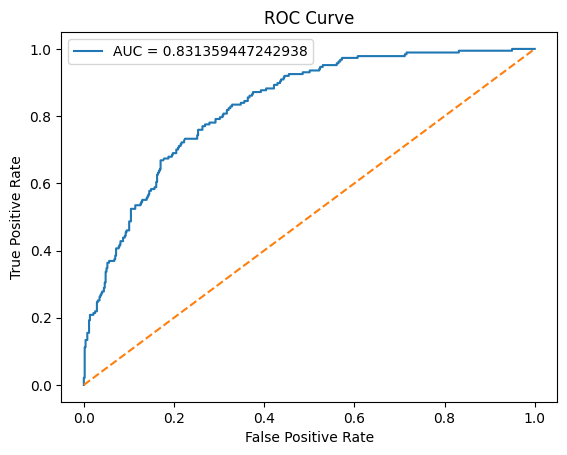

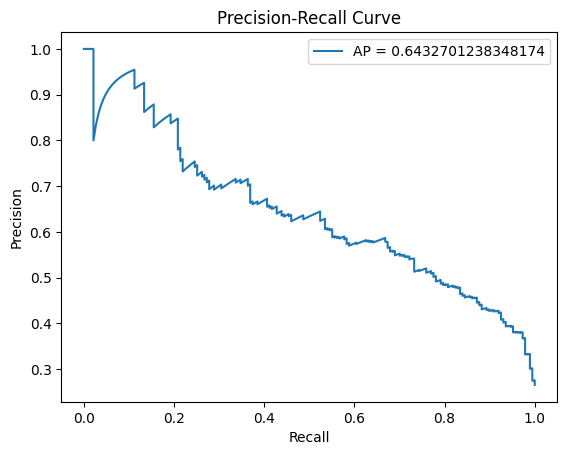

In [11]:
val_probs = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, val_probs)
precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

auc_score = roc_auc_score(y_val, val_probs)
ap_score = average_precision_score(y_val, val_probs)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {auc_score}")
plt.plot([0, 1], [0, 1], linestyle = "--")  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Evaluating Model

In [12]:
test_preds = model.predict(X_test)
test_probs = model.predict_proba(X_test)[:, 1]

accuracy, precision, recall, f1_score = compute_metrics(y_test, test_preds)
auc_score = roc_auc_score(y_test, test_probs)

print("Accuracy:{}".format(accuracy * 100))
print("Precision:{}".format(precision))
print("Recall:{}".format(recall))
print("F1-Score:{}".format(f1_score))
print("AUC score:{}".format(auc_score))

Accuracy:76.97228144989339
Precision:0.5480769230769231
Recall:0.7620320855614974
F1-Score:0.6375838926174497
AUC score:0.8350930005021459


# Saving Model Weights

In [13]:
#import joblib

#joblib.dump(model, "random_forest_model.joblib")